# Projeto Integrador - Análise de Dados de Supermercado

## 1. Introdução

Este projeto tem como objetivo desenvolver uma prova de conceito de um modelo de
Inteligência de Negócio (BI), utilizando técnicas de análise exploratória de dados
e visualização de informações.

Para isso, será utilizada uma base de dados contendo informações sobre vendas de
uma rede de supermercados, incluindo características das vendas, clientes, produtos,
filiais, formas de pagamento, valores comercializados e avaliações.

A análise será realizada utilizando as bibliotecas Pandas e NumPy para manipulação
e análise dos dados, e Matplotlib para a criação das visualizações.

Objetivos:
- Realizar análise exploratória de dados (EDA)
- Criar visualizações relevantes para tomada de decisão
- Interpretar os resultados sob a ótica de negócio

In [2]:
# ==========================
# 1. Importação de bibliotecas
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# ==========================
# 2. Carregamento da base
# ==========================

# Ajuste o caminho do arquivo conforme necessário
# Exemplo: '/content/SuperMarket Analysis.csv' no Google Colab
caminho_arquivo = 'SuperMarket Analysis.csv'

df = pd.read_csv("/content/SuperMarket Analysis.csv")

In [21]:
# Visualizar primeiras linhas
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [22]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## 3. Limpeza e tratamento dos dados

Nesta etapa vamos:
- Converter colunas de data e hora para tipos adequados
- Verificar valores nulos
- Criar colunas derivadas úteis para análise (ex.: dia da semana, horário)

In [23]:
# ==========================
# 3.1 Conversão de tipos
# ==========================

# Converter coluna Date para datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Converter coluna Time para datetime (apenas hora)
df['Time'] = pd.to_datetime(df['Time']).dt.time

# Conferir novamente
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

/tmp/ipykernel_1255/72588140.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time


In [24]:
# ==========================
# 3.2 Verificação de nulos e duplicatas
# ==========================

# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Verificar duplicatas
print("\nRegistros duplicados:", df.duplicated().sum())

# Remover duplicatas, se houver
df = df.drop_duplicates()

Valores nulos por coluna:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Registros duplicados: 0


In [25]:
# ==========================
# 3.3 Criação de colunas derivadas
# ==========================

# Criar coluna de dia da semana
df['DayOfWeek'] = df['Date'].dt.day_name()

# Criar coluna de hora (inteiro)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Criar coluna de período do dia (manhã/tarde/noite)
def periodo_do_dia(hora):
    if hora < 12:
        return 'Manhã'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['Period'] = df['Hour'].apply(periodo_do_dia)

df[['Date', 'Time', 'DayOfWeek', 'Hour', 'Period']].head()

,Date,Time,DayOfWeek,Hour,Period
0,2019-01-05,13:08:00,Saturday,13,Tarde
1,2019-03-08,10:29:00,Friday,10,Manhã
2,2019-03-03,13:23:00,Sunday,13,Tarde
3,2019-01-27,20:33:00,Sunday,20,Noite
4,2019-02-08,10:37:00,Friday,10,Manhã


## 4. Análise Exploratória de Dados (EDA)

Nesta etapa, exploramos os principais aspectos da base de dados que serão utilizados nas análises e visualizações do projeto. O foco está em entender o comportamento das vendas por categoria, filial, horário, forma de pagamento e lucro.


In [26]:
# ==========================
# 4.1 Visão geral da base
# ==========================

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Rating,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270,14.910000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858,3.186857


In [27]:
# ==========================
# 4.2 Faturamento por categoria de produto
# ==========================

df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [28]:
# ==========================
# 4.3 Faturamento por filial
# ==========================

df.groupby('Branch')['Sales'].sum()

,Sales
Branch,
Alex,106200.3705
Cairo,106197.6720
Giza,110568.7065


In [29]:
# ==========================
# 4.4 Vendas por horário
# ==========================

df.groupby('Hour')['Sales'].sum()

,Sales
Hour,
10,31421.4810
11,30377.3295
12,26065.8825
13,34723.2270
14,30828.3990
15,31179.5085
16,25226.3235
17,24445.2180
18,26030.3400


In [30]:
# ==========================
# 4.5 Formas de pagamento utilizadas
# ==========================

df['Payment'].value_counts()

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [31]:
# ==========================
# 4.6 Lucro por categoria de produto
# ==========================

df.groupby('Product line')['gross income'].sum().sort_values(ascending=False)

,gross income
Product line,
Food and beverages,2673.5640
Sports and travel,2624.8965
Electronic accessories,2587.5015
Fashion accessories,2585.9950
Home and lifestyle,2564.8530
Health and beauty,2342.5590


## 5. Visualizações para tomada de decisão

A seguir, vamos criar 5 visualizações diferentes e relevantes:

1. Faturamento por categoria de produto  
2. Faturamento por filial
3. Vendas por horário
4. Formas de pagamento utilizadas
5. Lucro por categoria de produto

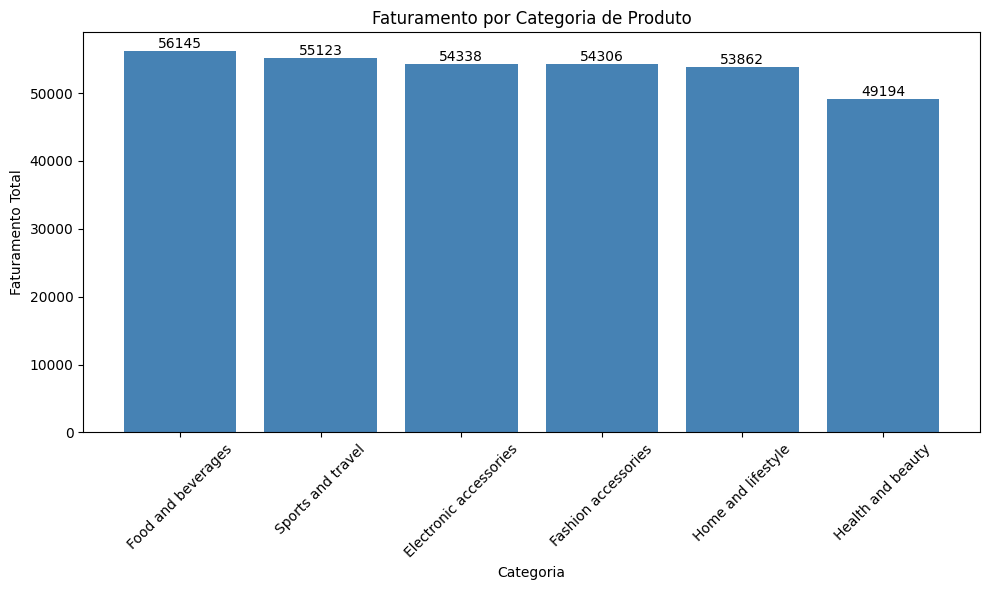

In [32]:
# ==========================
# 1. Faturamento por categoria de produto
# ==========================

faturamento_categoria = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(faturamento_categoria.index, faturamento_categoria.values, color='steelblue')

plt.title('Faturamento por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Faturamento Total')
plt.xticks(rotation=45)

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

plt.show()

**O que o gráfico mostra:**  
O total de faturamento gerado por cada categoria de produto, permitindo comparar quais linhas vendem mais.

**Qual decisão ele pode ajudar a tomar:**  
- Priorizar estoque e espaço nas categorias mais rentáveis.  
- Reforçar campanhas nas categorias com maior potencial de retorno.  
- Reavaliar categorias com baixo faturamento.

**Por que essa informação é útil:**  
Ajuda a direcionar recursos para os produtos que realmente impulsionam o faturamento do supermercado.

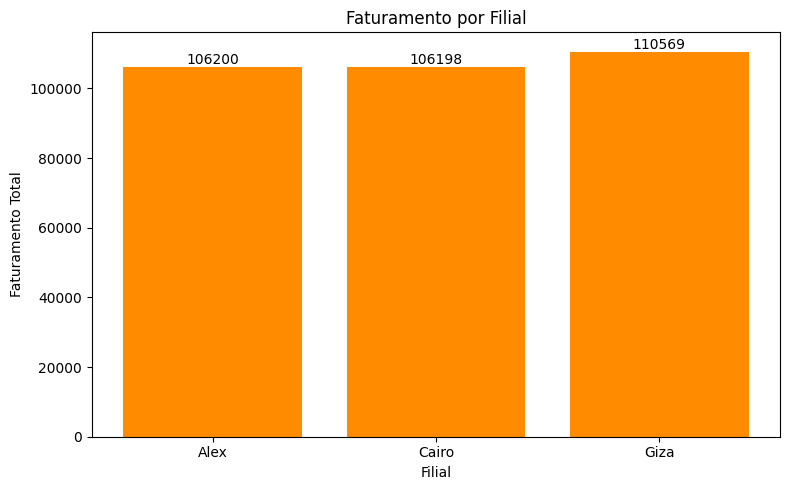

In [33]:
# ==========================
# 2. Faturamento por filial
# ==========================

faturamento_filial = df.groupby('Branch')['Sales'].sum()

plt.figure(figsize=(8,5))
bars = plt.bar(faturamento_filial.index, faturamento_filial.values, color='darkorange')

plt.title('Faturamento por Filial')
plt.xlabel('Filial')
plt.ylabel('Faturamento Total')

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
O desempenho de faturamento de cada filial, evidenciando diferenças entre unidades.

**Qual decisão ele pode ajudar a tomar:**  
- Identificar filiais com melhor desempenho para replicar boas práticas.  
- Focar ações corretivas nas unidades com faturamento mais baixo.  
- Planejar investimentos de forma mais estratégica.

**Por que essa informação é útil:**  
Permite entender onde o negócio é mais forte e onde há oportunidades de melhoria operacional.

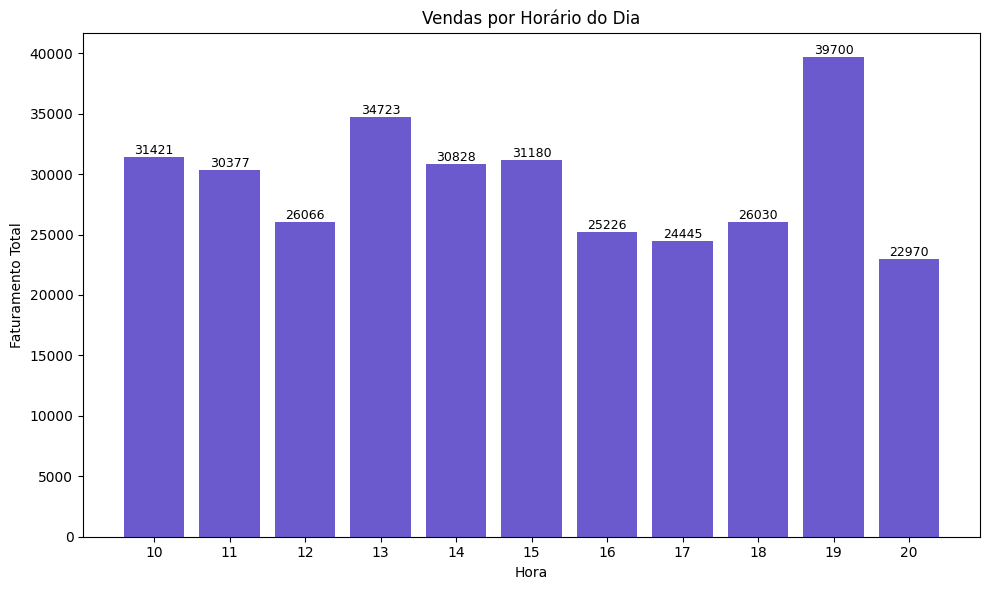

In [34]:
# ==========================
# 3. Vendas por horário
# ==========================

vendas_horario = df.groupby('Hour')['Sales'].sum()

plt.figure(figsize=(10,6))
bars = plt.bar(vendas_horario.index, vendas_horario.values, color='slateblue')

plt.title('Vendas por Horário do Dia')
plt.xlabel('Hora')
plt.ylabel('Faturamento Total')
plt.xticks(vendas_horario.index)

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
Os horários do dia com maior e menor volume de vendas, revelando padrões de fluxo de clientes.

**Qual decisão ele pode ajudar a tomar:**  
- Ajustar escala de funcionários conforme os horários de pico.  
- Planejar promoções em horários de baixa movimentação.  
- Otimizar o funcionamento da loja.

**Por que essa informação é útil:**  
Melhora a eficiência operacional e ajuda a aproveitar melhor os períodos de maior demanda.

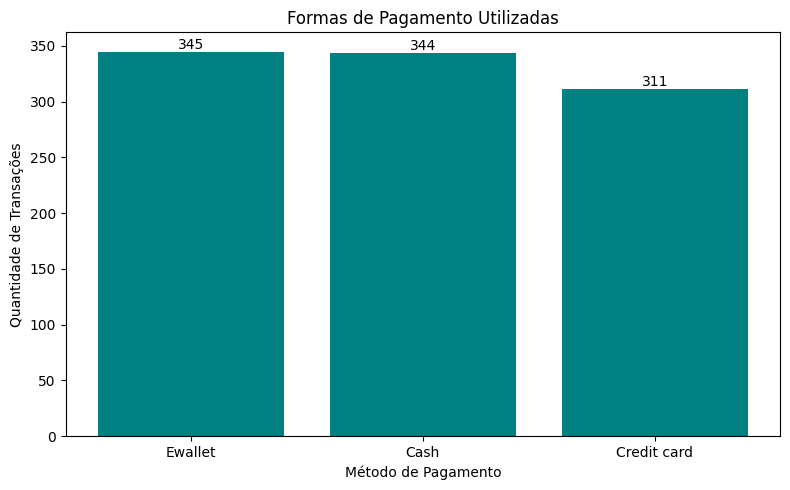

In [35]:
# ==========================
# 4. Formas de pagamento utilizadas
# ==========================

pagamento = df['Payment'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(pagamento.index, pagamento.values, color='teal')

plt.title('Formas de Pagamento Utilizadas')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Transações')

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
A quantidade de transações realizadas por cada método de pagamento (dinheiro, cartão, carteira digital).

**Qual decisão ele pode ajudar a tomar:**  
- Ajustar os meios de pagamento oferecidos conforme a preferência dos clientes.  
- Criar promoções específicas para métodos mais utilizados.  
- Avaliar a necessidade de incentivar métodos menos usados.

**Por que essa informação é útil:**  
Ajuda a alinhar a experiência de compra com o comportamento real dos clientes.


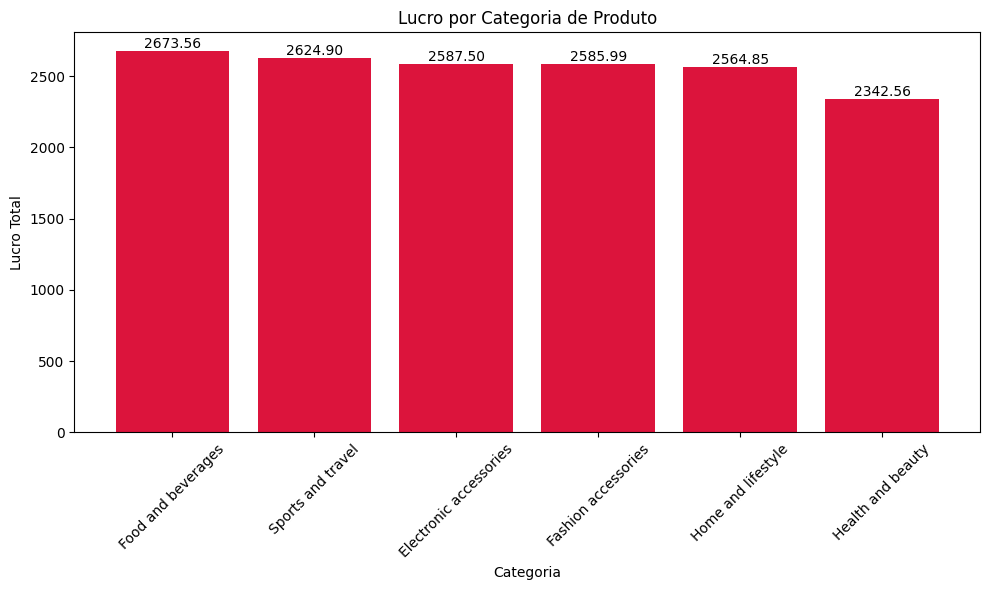

In [36]:
# ==========================
# 5. Lucro por categoria de produto
# ==========================

lucro_categoria = df.groupby('Product line')['gross income'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(lucro_categoria.index, lucro_categoria.values, color='crimson')

plt.title('Lucro por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Lucro Total')
plt.xticks(rotation=45)

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
O lucro total gerado por cada categoria de produto, permitindo identificar quais são mais rentáveis.

**Qual decisão ele pode ajudar a tomar:**  
- Priorizar categorias com maior margem de lucro.  
- Reavaliar categorias que vendem muito, mas geram pouco lucro.  
- Ajustar preços ou estratégias para melhorar rentabilidade.

**Por que essa informação é útil:**  
Foca não apenas no faturamento, mas no resultado real, ajudando a tomar decisões mais estratégicas.


## 6. Conclusão

### Conclusão Geral das Análises

A partir das visualizações geradas, é possível identificar pontos importantes sobre o desempenho do supermercado:

### 1. Faturamento por categoria de produto
As categorias apresentam diferenças de faturamento. Algumas linhas se destacam e puxam a receita, enquanto outras têm desempenho menor. Isso mostra onde o negócio é mais forte e onde há espaço para crescimento ou ajustes no mix de produtos.

### 2. Faturamento por filial
As filiais não têm o mesmo nível de faturamento. Isso evidencia oportunidades de reforçar ações locais nas filiais mais fracas e replicar boas práticas da filial líder.

### 3. Vendas por horário
Os horários apresentam variações de volume de vendas, com períodos mais movimentados e outros mais fracos. Esse padrão ajuda a ajustar escala de funcionários, otimizar horários de funcionamento e planejar promoções em momentos de baixa demanda.

### 4. Formas de pagamento utilizadas
Os clientes têm preferências entre dinheiro, cartão e carteira digital. Entender essa distribuição permite adaptar os meios de pagamento oferecidos e até criar promoções direcionadas para cada modalidade.

### 5. Lucro por categoria de produto
Algumas categorias não apenas faturam mais, mas também geram maior lucro. Outras podem vender bastante, mas com margem menor. Isso ajuda a priorizar categorias mais rentáveis e reavaliar estratégias para aquelas que têm bom faturamento, mas baixo retorno.

---

### Conclusão Final

De forma geral, as análises mostram que o supermercado possui categorias e filiais que impulsionam o faturamento, enquanto outras apresentam potencial de melhoria. A distribuição dos horários e das formas de pagamento revela padrões importantes de comportamento dos clientes. Já a análise de lucro por categoria destaca onde o negócio realmente ganha dinheiro.  

Esses insights ajudam a direcionar decisões de estoque, marketing, operação e estratégia comercial de forma mais eficiente e orientada por dados.